# Week 1 Lab — SOLUTIONS — Introduction & Mathematical Foundations

**MANG2074 Financial Econometrics 1**

**Objectives**

- Load and inspect financial data with `pandas`.
- Transform prices into simple and log returns.
- Compute and interpret summary statistics (mean, volatility, skewness, kurtosis).
- Test for normality with the Jarque–Bera test.

**Data**

- `../data/sp500.csv` — daily S&P 500 index level, 1950–2018 (`date`, `sp500`).
- `../data/ukhp.csv` — monthly UK average house price (Nationwide), 1991–2018 (`Month`, `Average House Price`).


## Task 1 — Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# index_col=0 makes the date column the index; parse_dates converts strings to Timestamps
sp = pd.read_csv('../data/sp500.csv', index_col=0, parse_dates=True)
hp = pd.read_csv('../data/ukhp.csv', index_col=0, parse_dates=True)

print(sp.info())
print(sp.head())
print(hp.info())
print(hp.head())
print(sp.describe())
print(hp.describe())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17247 entries, 1950-01-03 to 2018-07-18
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sp500   17247 non-null  float64
dtypes: float64(1)
memory usage: 269.5 KB
None
            sp500
date             
1950-01-03  16.66
1950-01-04  16.85
1950-01-05  16.93
1950-01-06  16.98
1950-01-09  17.08
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327 entries, 1991-01-01 to 2018-03-01
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Average House Price  327 non-null    float64
dtypes: float64(1)
memory usage: 5.1 KB
None
            Average House Price
Month                          
1991-01-01         53051.721106
1991-02-01         53496.798746
1991-03-01         52892.861606
1991-04-01         53677.435270
1991-05-01         54385.726747
              sp500
count  17247.000000
mean     

**What to interpret.** `sp500.csv` has 17,246 daily observations (1950–2018) and `ukhp.csv` 327 monthly observations (1991–2018); neither has missing values. The S&P column is the *level* of the index, not a return — the mean (~500) and enormous range (16.7 to 2,872) already hint that the level trends upwards and is not stationary.

## Task 2 — Plot the price levels

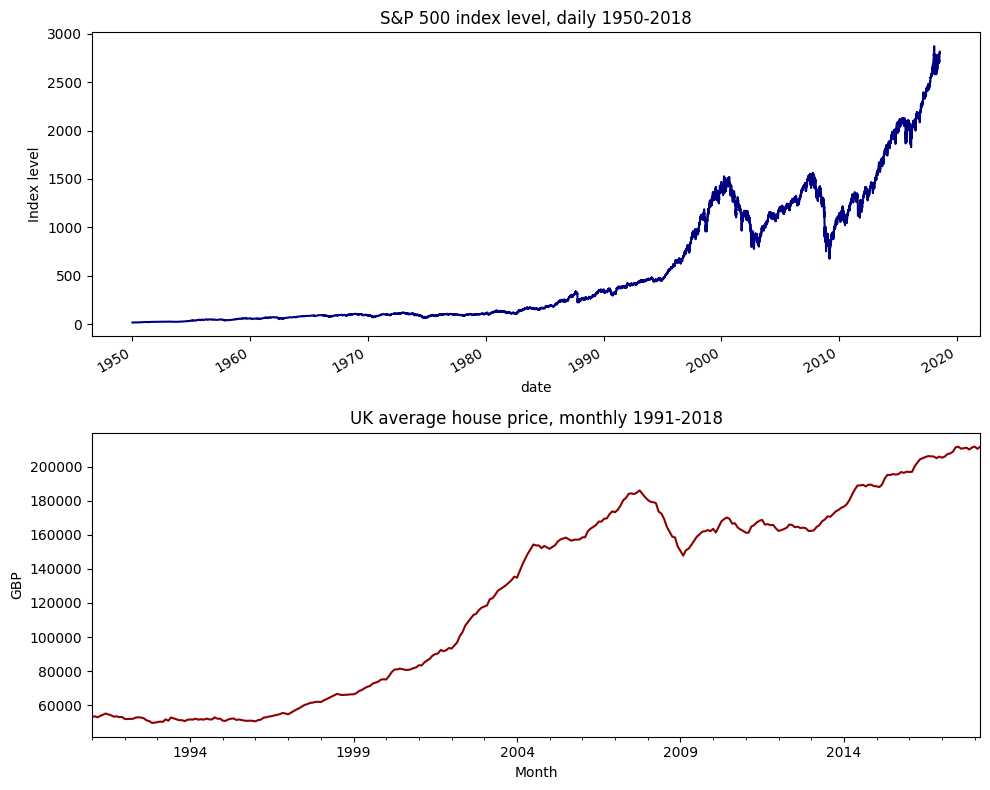

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
sp['sp500'].plot(ax=axes[0], color='navy')
axes[0].set_title('S&P 500 index level, daily 1950-2018')
axes[0].set_ylabel('Index level')

hp['Average House Price'].plot(ax=axes[1], color='darkred')
axes[1].set_title('UK average house price, monthly 1991-2018')
axes[1].set_ylabel('GBP')
plt.tight_layout()
plt.show()


**What to interpret.** Both series trend strongly upwards and never return to an earlier "mean level": they are clearly **non-stationary**. Classic episodes are visible — the 1987 crash is a blip, the dot-com bust (2000–02) and the global financial crisis (2008–09) are large drawdowns; UK house prices fall visibly in 2008–09. Because the level wanders, we transform to returns before computing statistics.

## Task 3 — Compute simple and log returns

In [3]:
# Simple return: R_t = 100*(P_t/P_{t-1} - 1)
sp['ret_simple'] = 100 * sp['sp500'].pct_change()
# Log return: r_t = 100*(ln P_t - ln P_{t-1})
sp['ret_log'] = 100 * np.log(sp['sp500']).diff()

# Monthly % change in house prices (simple return), as used throughout the module
hp['dhp'] = 100 * hp['Average House Price'].pct_change()

# Differencing creates a NaN in the first row - drop it
sp = sp.dropna()
hp = hp.dropna()
print(sp.head())
print(hp.head())


                sp500  ret_simple   ret_log
date                                       
1950-01-04  16.850000    1.140456  1.134002
1950-01-05  16.930000    0.474777  0.473654
1950-01-06  16.980000    0.295334  0.294898
1950-01-09  17.080000    0.588928  0.587201
1950-01-10  17.030001   -0.292734 -0.293163
            Average House Price       dhp
Month                                    
1991-02-01         53496.798746  0.838950
1991-03-01         52892.861606 -1.128922
1991-04-01         53677.435270  1.483326
1991-05-01         54385.726747  1.319533
1991-06-01         55107.375085  1.326908


## Task 4 — How different are simple and log returns?

In [4]:
diff = sp['ret_simple'] - sp['ret_log']
print(diff.describe())
print("\nFive largest absolute discrepancies (date, simple, log, diff):")
big = diff.abs().nlargest(5).index
print(sp.loc[big, ['ret_simple', 'ret_log']].assign(diff=diff[big]))


count    17246.000000
mean         0.004646
std          0.023952
min          0.000000
25%          0.000196
50%          0.001031
75%          0.003742
max          2.432798
dtype: float64

Five largest absolute discrepancies (date, simple, log, diff):
            ret_simple    ret_log      diff
date                                       
1987-10-19  -20.466931 -22.899729  2.432798
2008-10-13   11.580037  10.957197  0.622840
2008-10-28   10.789006  10.245736  0.543270
2008-10-15   -9.034978  -9.469512  0.434535
2008-12-01   -8.929524  -9.353652  0.424128


**What to interpret.** On a typical day the two definitions differ by less than a thousandth of a percentage point — for daily data the choice is immaterial. The discrepancies blow up only on extreme days, most dramatically 19 October 1987 (Black Monday): a simple return of about −20.5% corresponds to a log return of about −22.9%, because $\ln(1+x)\approx x$ breaks down for large $|x|$. Note also that the simple return always exceeds the log return ($r_t = \ln(1+R_t) \le R_t$).

## Task 5 — Plot the returns

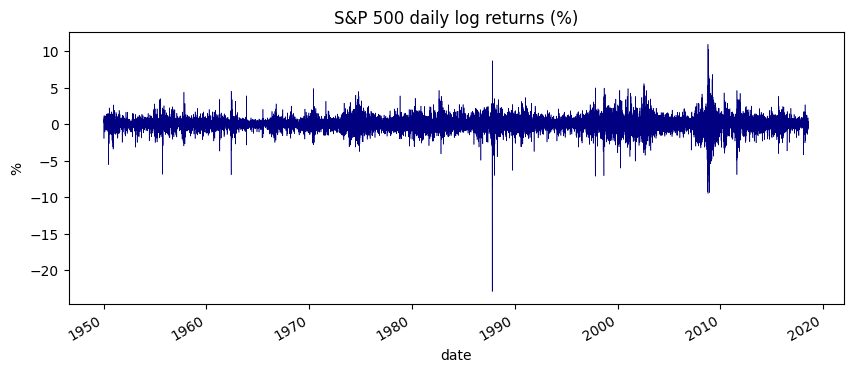

In [5]:
plt.figure(figsize=(10, 4))
sp['ret_log'].plot(color='navy', linewidth=0.4)
plt.title('S&P 500 daily log returns (%)')
plt.ylabel('%')
plt.show()


**What to interpret.** Unlike the level, the return series fluctuates around a roughly constant mean near zero — it looks stationary. But the *spread* is not constant: quiet stretches (mid-1960s, mid-1990s, 2004–06) alternate with violent ones (1974, 1987, 2008–09). This **volatility clustering** is the central stylised fact behind the ARCH/GARCH models of Weeks 7–8.

## Task 6 — Summary statistics

In [6]:
def moments(x, label):
    print(f"--- {label} ---")
    print(f"obs          : {len(x)}")
    print(f"mean         : {x.mean():8.4f}")
    print(f"std dev      : {x.std():8.4f}")
    print(f"skewness     : {x.skew():8.4f}")
    print(f"excess kurt. : {x.kurtosis():8.4f}   (raw kurtosis = {x.kurtosis()+3:.4f})")
    print()

moments(sp['ret_log'], 'S&P500 daily log returns (%)')
moments(hp['dhp'], 'UK house price growth, monthly (%)')

print("Annualised figures:")
print(f"S&P500   : mean = {252*sp['ret_log'].mean():6.2f}% p.a., vol = {np.sqrt(252)*sp['ret_log'].std():6.2f}% p.a.")
print(f"UK houses: mean = {12*hp['dhp'].mean():6.2f}% p.a., vol = {np.sqrt(12)*hp['dhp'].std():6.2f}% p.a.")


--- S&P500 daily log returns (%) ---
obs          : 17246
mean         :   0.0297
std dev      :   0.9648
skewness     :  -1.0171
excess kurt. :  27.1833   (raw kurtosis = 30.1833)

--- UK house price growth, monthly (%) ---
obs          : 326
mean         :   0.4315
std dev      :   1.1187
skewness     :  -0.0824
excess kurt. :   0.6359   (raw kurtosis = 3.6359)

Annualised figures:
S&P500   : mean =   7.50% p.a., vol =  15.32% p.a.
UK houses: mean =   5.18% p.a., vol =   3.88% p.a.


**What to interpret.** The S&P 500 earned roughly 7% per year over 1950–2018 with annualised volatility around 15% — the classic equity risk/return trade-off. Returns are *negatively skewed* (crashes outweigh booms) and hugely *leptokurtic* (excess kurtosis far above 0): tails are much fatter than normal. UK house-price growth averaged about 5–6% per year with far lower volatility, but remember this is an appraisal-style smoothed index, which understates true risk.

## Task 7 — Histogram vs the normal distribution

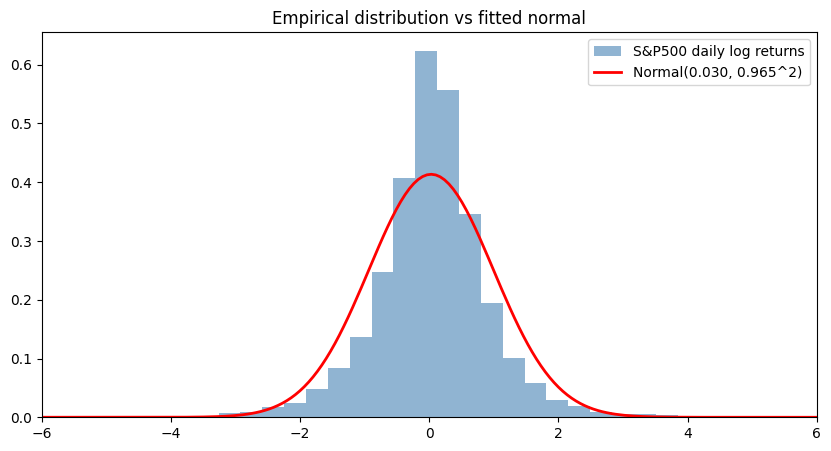

In [7]:
r = sp['ret_log']
x = np.linspace(r.min(), r.max(), 500)

plt.figure(figsize=(10, 5))
plt.hist(r, bins=100, density=True, alpha=0.6, color='steelblue',
         label='S&P500 daily log returns')
plt.plot(x, stats.norm.pdf(x, loc=r.mean(), scale=r.std()), 'r-', lw=2,
         label=f'Normal({r.mean():.3f}, {r.std():.3f}^2)')
plt.xlim(-6, 6)   # zoom on the body; the tails extend to -23% and +11%
plt.legend()
plt.title('Empirical distribution vs fitted normal')
plt.show()


**What to interpret.** Relative to the fitted normal, the empirical distribution has (i) a much taller, narrower **peak** around zero, (ii) thinner "shoulders", and (iii) far **fatter tails** — note the axis is truncated at ±6% yet the sample contains a −23% day, an event the normal model deems essentially impossible (it is a ~22-standard-deviation move). This peaked-with-fat-tails shape is the visual signature of leptokurtosis.

## Task 8 — Jarque–Bera test

In [8]:
def jb_by_hand(x):
    T = len(x)
    S = stats.skew(x)
    K = stats.kurtosis(x, fisher=False)   # raw kurtosis, normal = 3
    return T * (S**2/6 + (K-3)**2/24)

for series, label in [(sp['ret_log'], 'S&P500 daily log returns'),
                      (hp['dhp'], 'UK house price growth')]:
    jb_stat, jb_p = stats.jarque_bera(series)
    print(f"{label}:")
    print(f"  JB (scipy)   = {jb_stat:12.2f}, p-value = {jb_p:.4g}")
    print(f"  JB (by hand) = {jb_by_hand(series):12.2f}")
    print(f"  5% critical value of chi2(2) = {stats.chi2.ppf(0.95, 2):.2f}\n")


S&P500 daily log returns:
  JB (scipy)   =    533635.18, p-value = 0
  JB (by hand) =    533635.18
  5% critical value of chi2(2) = 5.99

UK house price growth:
  JB (scipy)   =         5.38, p-value = 0.06775
  JB (by hand) =         5.38
  5% critical value of chi2(2) = 5.99



**What to interpret.** $H_0$: the series is normally distributed (zero skewness *and* zero excess kurtosis); under $H_0$, $JB \sim \chi^2(2)$ with 5% critical value 5.99. For the S&P 500 the statistic is in the hundreds of thousands — rejection is overwhelming, driven mainly by the kurtosis term. UK house-price growth also rejects normality comfortably, though less spectacularly. Hand-computed and `scipy` values agree.

## Task 9 — Verdict

1. **Daily S&P 500 returns are emphatically not normal.** The JB test rejects at any conventional level. The dominant culprit is excess kurtosis (fat tails); the negative skewness contributes too, but kurtosis is an order of magnitude more important.
2. **It matters for risk management** because models assuming normality (e.g. a naive parametric VaR) will badly *understate* the probability of extreme losses: a 1987-style day is "impossible" under normality yet happened. Fat tails are exactly what GARCH models (Week 7) and Student-t errors (Week 8) are designed to capture.
3. **We analysed returns, not levels,** because price levels trend and are non-stationary, so their sample moments are not meaningful estimates of anything stable, and standard test statistics are invalid. Returns are (approximately) stationary, making the mean, volatility, skewness, kurtosis and JB test interpretable.